# 1. Descarga del conjunto de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
result = pyreadr.read_r('listings.RData')

In [3]:
df = result[list(result.keys())[0]]

In [4]:
df.shape

(171748, 80)

In [5]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171748 entries, 0 to 171747
Data columns (total 80 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            171748 non-null  float64
 1   listing_url                                   171748 non-null  object 
 2   scrape_id                                     171748 non-null  float64
 3   last_scraped                                  171748 non-null  object 
 4   source                                        171748 non-null  object 
 5   name                                          171748 non-null  object 
 6   description                                   171748 non-null  object 
 7   neighborhood_overview                         171748 non-null  object 
 8   picture_url                                   171748 non-null  object 
 9   host_id                                       17

In [7]:
df.describe()

,id,scrape_id,host_id,latitude,longitude,accommodates,bathrooms,minimum_nights,maximum_nights,minimum_nights_avg_ntm,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.717480e+05,1.717480e+05,1.717480e+05,171748.000000,171748.000000,171748.000000,140352.000000,171748.000000,1.717480e+05,171748.000000,...,131446.000000,131424.000000,131440.000000,131420.000000,131420.000000,171748.000000,171748.000000,171748.000000,171748.000000,131461.000000
mean,6.362915e+17,2.025107e+13,2.002571e+08,33.776320,-109.489530,4.106796,1.551795,16.996559,1.298827e+04,17.487677,...,4.752217,4.859050,4.852813,4.804140,4.690129,45.879987,39.608950,5.539005,0.082114,1.344455
std,5.834928e+17,1.419625e+08,2.048830e+08,7.236441,30.024424,2.836661,1.014407,30.014597,5.181840e+06,30.788964,...,0.411183,0.335401,0.358002,0.344275,0.428966,135.161293,131.065101,37.500862,1.643607,1.788745
min,6.000000e+00,2.025092e+13,2.300000e+01,18.989648,-159.716528,1.000000,0.000000,1.000000,1.000000e+00,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.599300e+07,2.025092e+13,2.633063e+07,30.381088,-118.591115,2.000000,1.000000,2.000000,9.000000e+01,2.000000,...,4.690000,4.860000,4.860000,4.750000,4.620000,1.000000,1.000000,0.000000,0.000000,0.190000
50%,7.249557e+17,2.025120e+13,1.080585e+08,34.089840,-117.865347,4.000000,1.000000,4.000000,3.650000e+02,4.400000,...,4.880000,4.960000,4.960000,4.910000,4.800000,3.000000,1.000000,0.000000,0.000000,0.700000
75%,1.182638e+18,2.025120e+13,3.765745e+08,40.702460,-73.997148,6.000000,2.000000,30.000000,1.125000e+03,30.000000,...,5.000000,5.000000,5.000000,5.000000,4.920000,21.000000,12.000000,1.000000,0.000000,2.000000
max,1.567804e+18,2.025120e+13,7.320923e+08,42.391844,-70.996000,16.000000,32.500000,1125.000000,2.147484e+09,1125.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1189.000000,1189.000000,567.000000,60.000000,120.370000


In [8]:
df['price'].head

<bound method NDFrame.head of 0          $97.00
1         $160.00
2          $38.00
3         $145.00
4          $58.00
           ...   
171743        NaN
171744        NaN
171745        NaN
171746        NaN
171747        NaN
Name: price, Length: 171748, dtype: object>

Se verificó que todos los precios fueran en dólares antes de convertirlos de object a float

In [9]:
df['price'].str.extract(r'([^0-9.,])').value_counts()

0
$    76246
Name: count, dtype: int64

In [10]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [11]:
df['price'].dtype

dtype('float64')

In [12]:
df.describe()

,id,scrape_id,host_id,latitude,longitude,accommodates,bathrooms,price,minimum_nights,maximum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.717480e+05,1.717480e+05,1.717480e+05,171748.000000,171748.000000,171748.000000,140352.000000,76246.000000,171748.000000,1.717480e+05,...,131446.000000,131424.000000,131440.000000,131420.000000,131420.000000,171748.000000,171748.000000,171748.000000,171748.000000,131461.000000
mean,6.362915e+17,2.025107e+13,2.002571e+08,33.776320,-109.489530,4.106796,1.551795,750.509220,16.996559,1.298827e+04,...,4.752217,4.859050,4.852813,4.804140,4.690129,45.879987,39.608950,5.539005,0.082114,1.344455
std,5.834928e+17,1.419625e+08,2.048830e+08,7.236441,30.024424,2.836661,1.014407,4250.606945,30.014597,5.181840e+06,...,0.411183,0.335401,0.358002,0.344275,0.428966,135.161293,131.065101,37.500862,1.643607,1.788745
min,6.000000e+00,2.025092e+13,2.300000e+01,18.989648,-159.716528,1.000000,0.000000,8.000000,1.000000,1.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.599300e+07,2.025092e+13,2.633063e+07,30.381088,-118.591115,2.000000,1.000000,120.000000,2.000000,9.000000e+01,...,4.690000,4.860000,4.860000,4.750000,4.620000,1.000000,1.000000,0.000000,0.000000,0.190000
50%,7.249557e+17,2.025120e+13,1.080585e+08,34.089840,-117.865347,4.000000,1.000000,193.000000,4.000000,3.650000e+02,...,4.880000,4.960000,4.960000,4.910000,4.800000,3.000000,1.000000,0.000000,0.000000,0.700000
75%,1.182638e+18,2.025120e+13,3.765745e+08,40.702460,-73.997148,6.000000,2.000000,326.000000,30.000000,1.125000e+03,...,5.000000,5.000000,5.000000,5.000000,4.920000,21.000000,12.000000,1.000000,0.000000,2.000000
max,1.567804e+18,2.025120e+13,7.320923e+08,42.391844,-70.996000,16.000000,32.500000,50123.000000,1125.000000,2.147484e+09,...,5.000000,5.000000,5.000000,5.000000,5.000000,1189.000000,1189.000000,567.000000,60.000000,120.370000


In [13]:
df.isnull().sum().sort_values(ascending=False).head(20)

calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
reviews_per_month                40287
review_scores_rating             40287
beds                             31686
bathrooms                        31396
license                          10533
bedrooms                         10473
host_total_listings_count          876
host_listings_count                876
maximum_maximum_nights              71
maximum_minimum_nights              71
dtype: int64

In [14]:
df['price'].describe()

count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64

In [15]:
df = df.dropna(subset=['price'])

In [16]:
df.shape

(76246, 80)

# 2. Análisis exploratorio extenso de los datos

In [17]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True)

/var/folders/xv/g38xvw9j28vc78v68ljk5g900000gn/T/ipykernel_11407/2553420828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = df['price'].replace(r'[\$,]', '', regex=True)


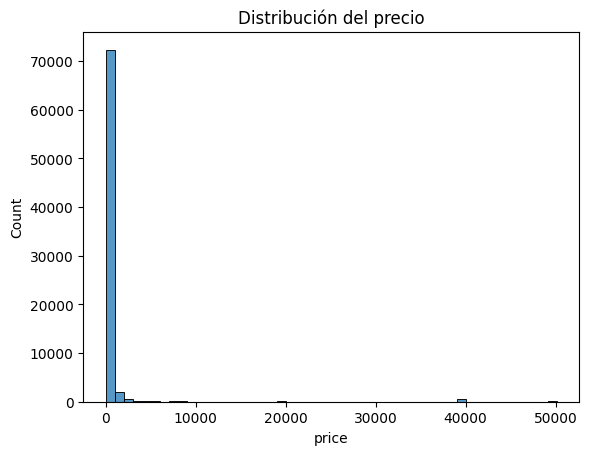

In [18]:
plt.figure()
sns.histplot(df['price'], bins=50)
plt.title('Distribución del precio')
plt.show()

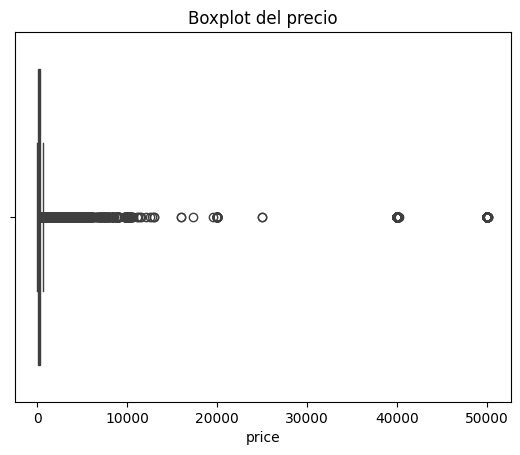

In [19]:
plt.figure()
sns.boxplot(x=df['price'])
plt.title('Boxplot del precio')
plt.show()

In [20]:
df['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25     120.0
0.50     193.0
0.75     326.0
0.90     629.0
0.95    1034.0
Name: price, dtype: float64

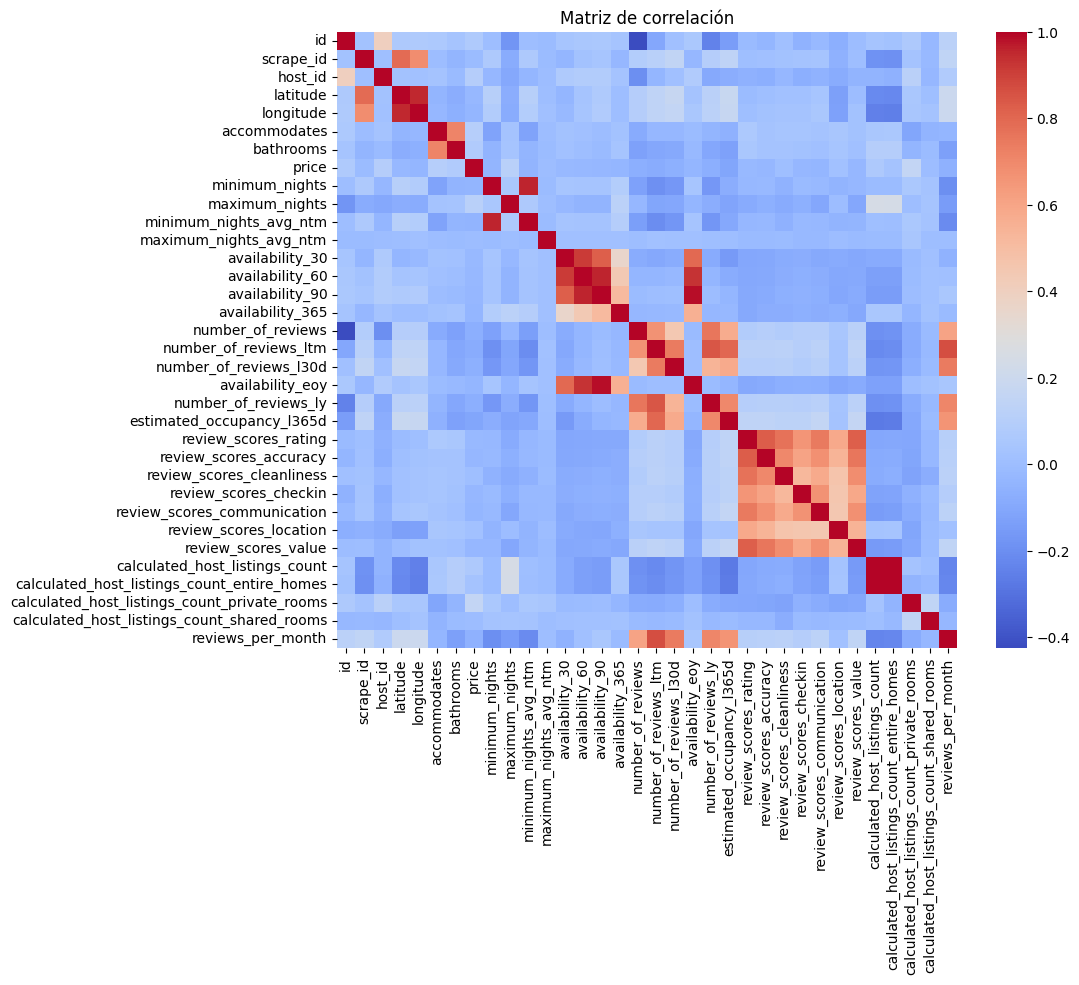

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [22]:
corr['price'].sort_values(ascending=False)

price                                           1.000000
calculated_host_listings_count_private_rooms    0.154335
maximum_nights                                  0.111292
accommodates                                    0.099671
host_id                                         0.095678
bathrooms                                       0.079704
id                                              0.073913
calculated_host_listings_count                  0.067503
calculated_host_listings_count_entire_homes     0.027066
review_scores_location                          0.017559
review_scores_cleanliness                       0.007770
maximum_nights_avg_ntm                         -0.003881
calculated_host_listings_count_shared_rooms    -0.006960
scrape_id                                      -0.011021
review_scores_rating                           -0.018521
availability_30                                -0.020832
availability_60                                -0.027714
latitude                       

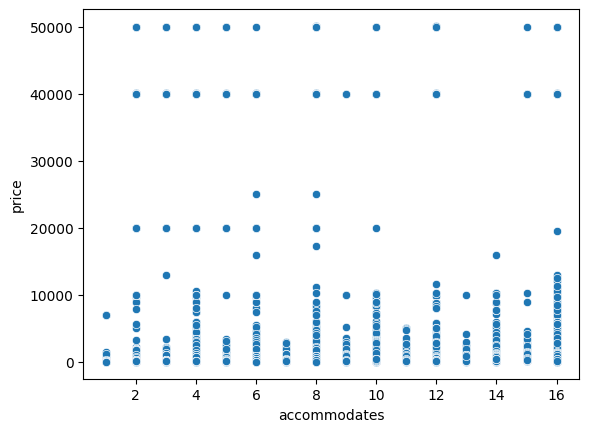

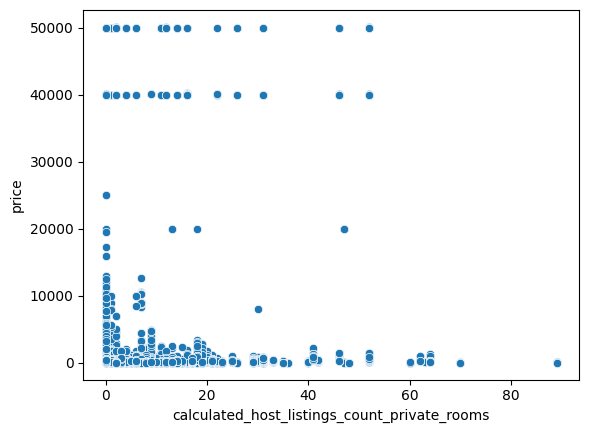

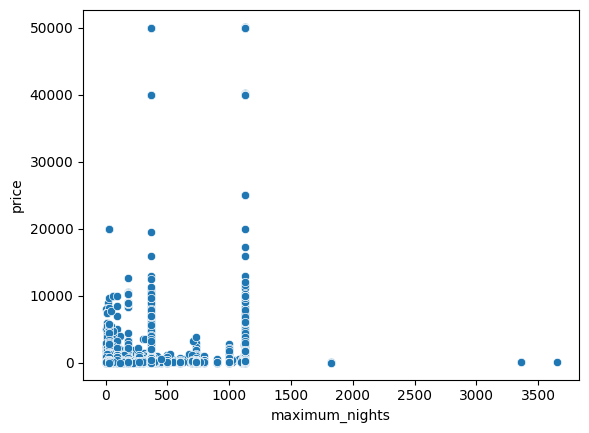

In [23]:
sns.scatterplot(x=df['accommodates'], y=df['price'])
plt.show()

sns.scatterplot(x=df['calculated_host_listings_count_private_rooms'], y=df['price'])
plt.show()

sns.scatterplot(x=df['maximum_nights'], y=df['price'])
plt.show()

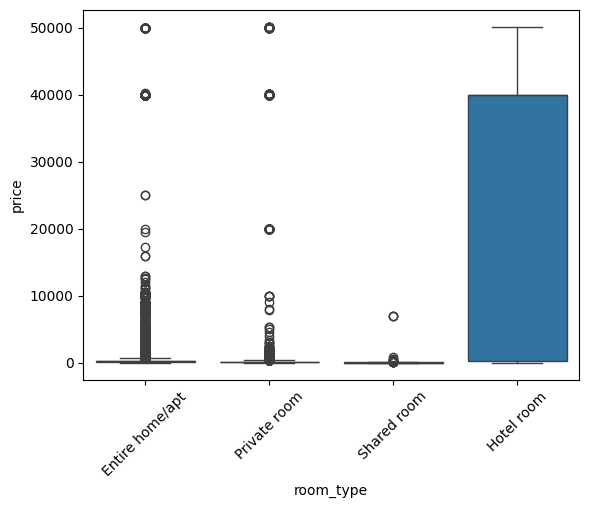

In [24]:
sns.boxplot(x='room_type', y='price', data=df)
plt.xticks(rotation=45)
plt.show()

# 3. Análisis de grupos en la EDA

In [25]:
y = df['price']

X = df.select_dtypes(include=['int64', 'float64']).copy()
X = X.drop(columns=['price'], errors='ignore')

cols_to_keep = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating'
]

In [26]:
imputer = SimpleImputer(strategy='mean')
X_final = imputer.fit_transform(X)

/usr/local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [27]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y,
    test_size=0.3,
    random_state=42
)

In [28]:
# entrenar y evaluar el arbol con todas las variables
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train_f, y_train_f)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [29]:
y_pred_f = tree_full.predict(X_test_f)

In [30]:
print("R2 (todas las variables):", r2_score(y_test_f, y_pred_f))
print("MSE (todas las variables):", mean_squared_error(y_test_f, y_pred_f))

R2 (todas las variables): 0.5030431268326037
MSE (todas las variables): 9028506.38808254


# ANALISIS DE GRUPOS

In [31]:
group_analysis = df.groupby('room_type')['price'].agg(['mean', 'median', 'count'])
group_analysis

,mean,median,count
room_type,,,
Entire home/apt,505.122921,205.0,65709
Hotel room,24477.200308,40000.0,649
Private room,838.869637,85.0,9673
Shared room,149.372093,42.0,215


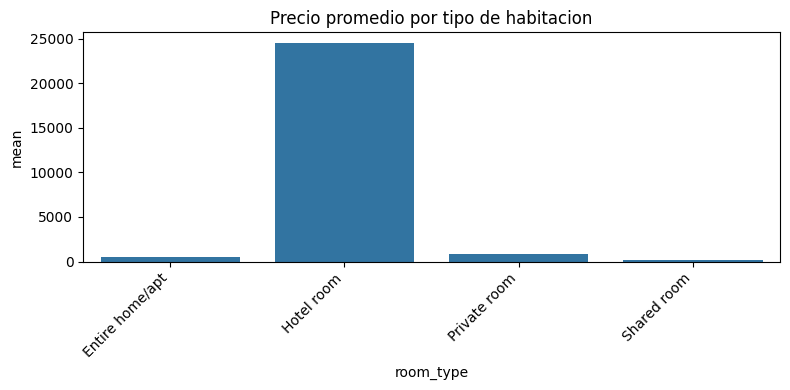

In [32]:
group_plot = group_analysis.reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=group_plot, x='room_type', y='mean')
plt.xticks(rotation=45, ha='right')
plt.title('Precio promedio por tipo de habitacion')
plt.tight_layout()
plt.show()

# 4. División en entrenamiento y prueba

In [33]:
print("Filas entrenamiento (X_train_f):", len(X_train_f))
print("Filas prueba (X_test_f):", len(X_test_f))
print("Shape X_train_f:", X_train_f.shape)
print("Shape X_test_f:", X_test_f.shape)

Filas entrenamiento (X_train_f): 53372
Filas prueba (X_test_f): 22874
Shape X_train_f: (53372, 15)
Shape X_test_f: (22874, 15)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [35]:
X_train.shape, X_test.shape

((53372, 15), (22874, 15))

In [37]:
X_train.to_csv("data/X_train.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)

pd.Series(y_train).to_csv("data/y_train.csv", index=False)
pd.Series(y_test).to_csv("data/y_test.csv", index=False)

# 5. Arbol de regresión

In [ ]:
df_model = df[cols_to_keep + ['price']].copy()

y = df_model['price']
X = df_model.drop(columns=['price'])

X_encoded = pd.get_dummies(X, drop_first=True)

# volver a dividir el dataset con las variables codificadas
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42
)

# entrenar un modelo de regresión

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [ ]:
# predecir en el conjunto de prueba

y_pred = tree.predict(X_test)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


# 6. Presición y análisis del resultado

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 12994822.700815419
R2: 0.28472482831864687


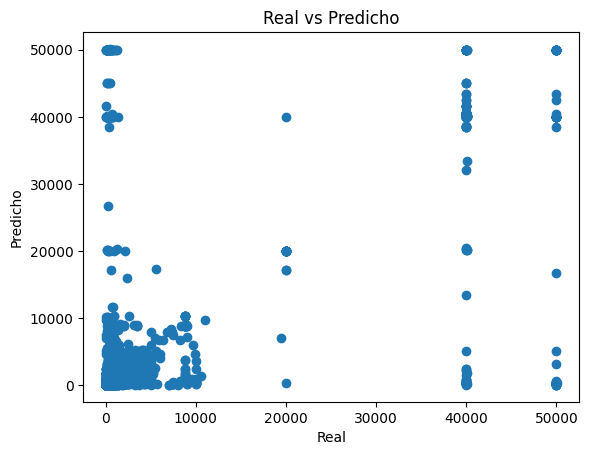

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.show()

# 7. Modelos adicionales con distinta profundidad

In [ ]:
depths = [3, 5, 7, 10, 15, 20]

train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/

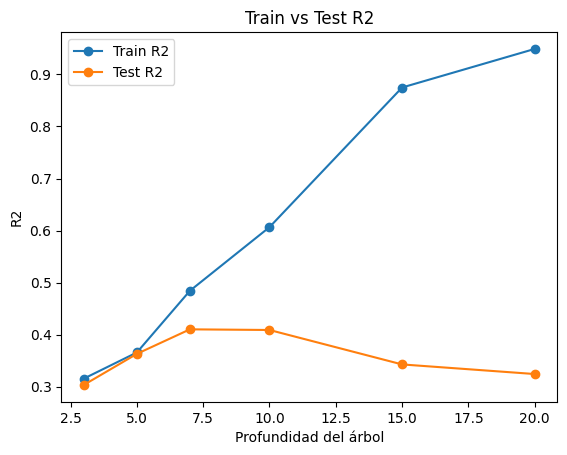

In [ ]:
plt.plot(depths, train_scores, marker='o', label='Train R2')
plt.plot(depths, test_scores, marker='o', label='Test R2')

plt.xlabel('Profundidad del árbol')
plt.ylabel('R2')
plt.title('Train vs Test R2')
plt.legend()
plt.show()

In [ ]:
best_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
best_tree.fit(X_train, y_train)

y_pred_best = best_tree.predict(X_test)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=copy)


In [ ]:
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("MSE (mejor modelo):", mse_best)
print("R2 (mejor modelo):", r2_best)

MSE (mejor modelo): 10736267.04154557
R2 (mejor modelo): 0.40904270660988074


# 8. Regresión lineal y comparación con el mejor árbol

In [ ]:
imputer = SimpleImputer(strategy='mean')

In [ ]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/escu/Documents/Universidad/Semestres/7moSemestre/mineriaDatos/Lab6-MD/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [ ]:
print("Árbol de regresión:")
print("R2:", r2_best)
print("MSE:", mse_best)

print("\nRegresión lineal:")
print("R2:", r2_lr)
print("MSE:", mse_lr)

Árbol de regresión:
R2: 0.40904270660988074
MSE: 10736267.04154557

Regresión lineal:
R2: 0.2127550938350533
MSE: 14302338.991700595


# 9. Creación de variable de respuesta categórica

In [ ]:
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)
print("P33:", q33, "| P66:", q66)
print("Límites elegidos: Económico <= 120 < Intermedio <= 326 < Caro")

P33: 141.0 | P66: 264.0
Límites elegidos: Económico <= 120 < Intermedio <= 326 < Caro


In [ ]:
def categorize_price(price):
    if price <= 120:
        return 'Economico'
    elif price <= 326:
        return 'Intermedio'
    else:
        return 'Caro'

# crear variable categórica sobre TODO el df
df['price_category'] = df['price'].apply(categorize_price)

In [ ]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [ ]:
y_class = df['price_category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_final, y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class
)

In [ ]:
y_pred_c = clf.predict(X_test_c)